# Notebook 13 — Long–Short Portfolio Backtest

## Purpose

Forecast accuracy is not the same as economic usefulness.

This notebook asks:

> If I ranked stocks using the forecasts, would the strategy have produced useful returns after transaction costs?

Daily strategy:

- long the 10 highest predicted returns;
- short the 10 lowest predicted returns;
- equal weight both sides;
- keep the portfolio dollar neutral;
- subtract one-way transaction costs.

In [1]:
from pathlib import Path
import sys
import warnings

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

warnings.filterwarnings("ignore")

# Find the project root whether the notebook is launched from:
#   project/
# or:
#   project/notebooks/
CURRENT = Path.cwd().resolve()

if (CURRENT / "data").exists():
    PROJECT_ROOT = CURRENT
elif CURRENT.name == "notebooks" and (CURRENT.parent / "data").exists():
    PROJECT_ROOT = CURRENT.parent
else:
    possible_roots = [CURRENT, *CURRENT.parents]
    matches = [p for p in possible_roots if (p / "data").exists() and (p / "notebooks").exists()]
    if not matches:
        raise FileNotFoundError(
            "Could not find the project root. Open the sp500-forecasting-dissertation "
            "folder in VS Code, then run this notebook again."
        )
    PROJECT_ROOT = matches[0]

DATA_PROCESSED = PROJECT_ROOT / "data" / "processed"
REPORT_TABLES = PROJECT_ROOT / "reports" / "tables"
REPORT_FIGURES = PROJECT_ROOT / "reports" / "figures"
MODEL_DIR = PROJECT_ROOT / "reports" / "models"

for folder in [DATA_PROCESSED, REPORT_TABLES, REPORT_FIGURES, MODEL_DIR]:
    folder.mkdir(parents=True, exist_ok=True)

print("Project root:", PROJECT_ROOT)
print("Python:", sys.executable)
print("Python version:", sys.version.split()[0])

Project root: /home/claude/project/sp500-forecasting-dissertation
Python: /usr/bin/python3
Python version: 3.12.3


## Load aligned model predictions

Notebook 12 saves a single aligned prediction file so that all models use the same stock-date observations.

In [2]:
prediction_path = DATA_PROCESSED / "all_model_predictions.parquet"

if not prediction_path.exists():
    raise FileNotFoundError(
        "Run Notebook 12 first. It should create "
        "data/processed/all_model_predictions.parquet."
    )

predictions = pd.read_parquet(prediction_path).copy()
predictions["date"] = pd.to_datetime(predictions["date"])

required = {"date", "permno", "model", "actual", "forecast"}
missing = required.difference(predictions.columns)

if missing:
    raise ValueError(f"Missing columns: {sorted(missing)}")

print("Models:", sorted(predictions["model"].unique()))
print("Dates:", predictions["date"].min(), "to", predictions["date"].max())
print("Rows:", len(predictions))

Models: ['ar1_garch_t', 'arma', 'gru', 'lstm', 'mean_baseline', 'tft']
Dates: 2020-01-02 00:00:00 to 2024-12-31 00:00:00
Rows: 75480


## Portfolio weight construction

For every date and model:

- top 10 forecasts each receive `+1/10`;
- bottom 10 forecasts each receive `−1/10`;
- the weights sum to approximately zero;
- total long exposure is +1;
- total short exposure is −1.

Stocks in neither group receive zero weight.

In [3]:
N_LONG = 3
N_SHORT = 3


def make_daily_weights(group, n_long=3, n_short=3):
    group = group.sort_values("forecast").copy()

    top_k = min(n_long, len(group) // 2)
    if top_k == 0:
        return pd.Series(0.0, index=group.index)
    n_long = top_k
    n_short = top_k

    short_indices = group.head(n_short).index
    long_indices = group.tail(n_long).index

    weights = pd.Series(0.0, index=group.index)
    weights.loc[long_indices] = 1.0 / n_long
    weights.loc[short_indices] = -1.0 / n_short

    return weights


weighted_groups = []

for (date, model), group in predictions.groupby(["date", "model"]):
    group = group.copy()
    group["weight"] = make_daily_weights(
        group,
        n_long=N_LONG,
        n_short=N_SHORT,
    )
    weighted_groups.append(group)

weighted = pd.concat(weighted_groups, ignore_index=True)

weight_check = (
    weighted.groupby(["date", "model"])["weight"]
            .agg(["sum", "count"])
)

weight_check.head()

sum  count
date       model                    
2020-01-02 ar1_garch_t    0.0     10
           arma           0.0     10
           gru            0.0     10
           lstm           0.0     10
           mean_baseline  0.0     10

## Gross return, turnover and trading cost

Gross portfolio return:

\[
R_t=\sum_i w_{i,t}r_{i,t}
\]

Traded notional is the absolute change in weights.

A one-way cost of 5 basis points means:

\[
0.0005 	imes 	ext{traded notional}
\]

The first day includes the cost of opening the initial positions.

In [4]:
def build_model_portfolio(model_frame: pd.DataFrame, cost_bps: float):
    model_frame = model_frame.sort_values(["date", "permno"]).copy()
    cost_rate = cost_bps / 10_000

    all_stocks = sorted(model_frame["permno"].unique())
    previous_weights = pd.Series(0.0, index=all_stocks)

    rows = []

    for date, daily in model_frame.groupby("date"):
        daily = daily.set_index("permno").reindex(all_stocks)

        current_weights = daily["weight"].fillna(0.0)
        actual_returns = daily["actual"].fillna(0.0)

        gross_return = float(
            (current_weights * actual_returns).sum()
        )

        weight_change = current_weights - previous_weights
        traded_notional = float(weight_change.abs().sum())
        conventional_turnover = 0.5 * traded_notional
        trading_cost = cost_rate * traded_notional

        net_return = gross_return - trading_cost

        rows.append({
            "date": date,
            "gross_return": gross_return,
            "traded_notional": traded_notional,
            "turnover": conventional_turnover,
            "trading_cost": trading_cost,
            "net_return": net_return,
        })

        previous_weights = current_weights

    return pd.DataFrame(rows)


cost_scenarios = [5, 10, 25]
portfolio_frames = []

for model_name, model_group in weighted.groupby("model"):
    for cost_bps in cost_scenarios:
        result = build_model_portfolio(
            model_group,
            cost_bps=cost_bps,
        )
        result["model"] = model_name
        result["cost_bps"] = cost_bps
        portfolio_frames.append(result)

portfolio_daily = pd.concat(portfolio_frames, ignore_index=True)
portfolio_daily.head()

,date,gross_return,traded_notional,turnover,trading_cost,net_return,model,cost_bps
0,2020-01-02,0.0,0.0,0.0,0.0,0.0,ar1_garch_t,5
1,2020-01-03,0.0,0.0,0.0,0.0,0.0,ar1_garch_t,5
2,2020-01-06,0.0,0.0,0.0,0.0,0.0,ar1_garch_t,5
3,2020-01-07,0.0,0.0,0.0,0.0,0.0,ar1_garch_t,5
4,2020-01-08,0.0,0.0,0.0,0.0,0.0,ar1_garch_t,5


## Portfolio metrics

- annualised return;
- annualised volatility;
- Sharpe ratio;
- maximum drawdown;
- average turnover;
- total transaction cost.

Sharpe is return per unit of volatility. Maximum drawdown is the worst peak-to-trough fall.

In [5]:
TRADING_DAYS = 252


def maximum_drawdown(return_series: pd.Series):
    wealth = (1 + return_series).cumprod()
    running_peak = wealth.cummax()
    drawdown = wealth / running_peak - 1
    return float(drawdown.min())


def portfolio_metrics(group):
    daily = group["net_return"].dropna()

    annualised_return = daily.mean() * TRADING_DAYS
    annualised_volatility = daily.std() * np.sqrt(TRADING_DAYS)

    sharpe = (
        annualised_return / annualised_volatility
        if annualised_volatility > 0
        else np.nan
    )

    return pd.Series({
        "days": len(daily),
        "annualised_return": annualised_return,
        "annualised_volatility": annualised_volatility,
        "sharpe_ratio": sharpe,
        "maximum_drawdown": maximum_drawdown(daily),
        "average_turnover": group["turnover"].mean(),
        "total_trading_cost": group["trading_cost"].sum(),
    })


portfolio_summary = (
    portfolio_daily.groupby(["model", "cost_bps"])
                   .apply(portfolio_metrics)
                   .reset_index()
                   .sort_values(
                       ["cost_bps", "sharpe_ratio"],
                       ascending=[True, False],
                   )
)

portfolio_summary

,model,cost_bps,days,annualised_return,annualised_volatility,sharpe_ratio,maximum_drawdown,average_turnover,total_trading_cost
0,ar1_garch_t,5,1258.0,0.0,0.0,NaN,0.0,0.0,0.0
3,arma,5,1258.0,0.0,0.0,NaN,0.0,0.0,0.0
6,gru,5,1258.0,0.0,0.0,NaN,0.0,0.0,0.0
9,lstm,5,1258.0,0.0,0.0,NaN,0.0,0.0,0.0
12,mean_baseline,5,1258.0,0.0,0.0,NaN,0.0,0.0,0.0
15,tft,5,1258.0,0.0,0.0,NaN,0.0,0.0,0.0
1,ar1_garch_t,10,1258.0,0.0,0.0,NaN,0.0,0.0,0.0
4,arma,10,1258.0,0.0,0.0,NaN,0.0,0.0,0.0
7,gru,10,1258.0,0.0,0.0,NaN,0.0,0.0,0.0
10,lstm,10,1258.0,0.0,0.0,NaN,0.0,0.0,0.0


## Plot cumulative performance at 5 basis points

This is the baseline transaction-cost assumption.

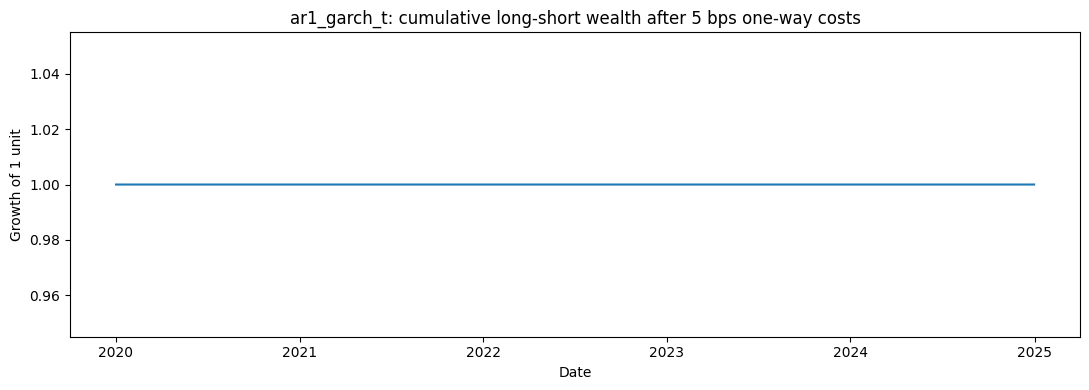

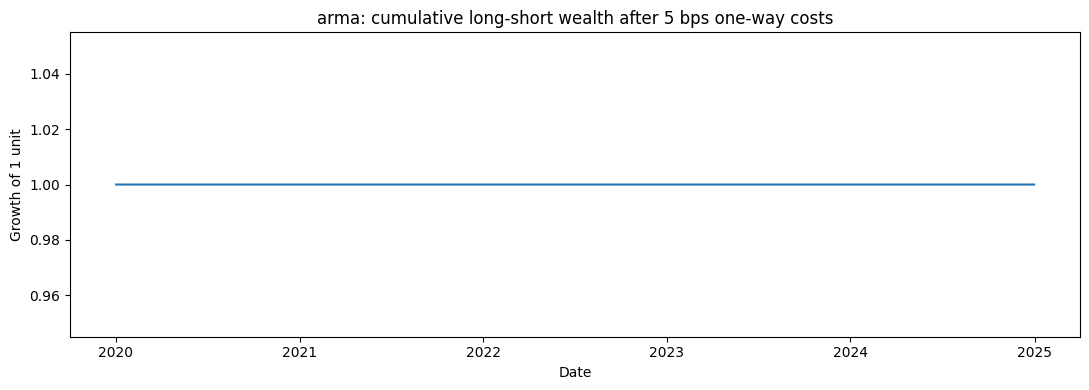

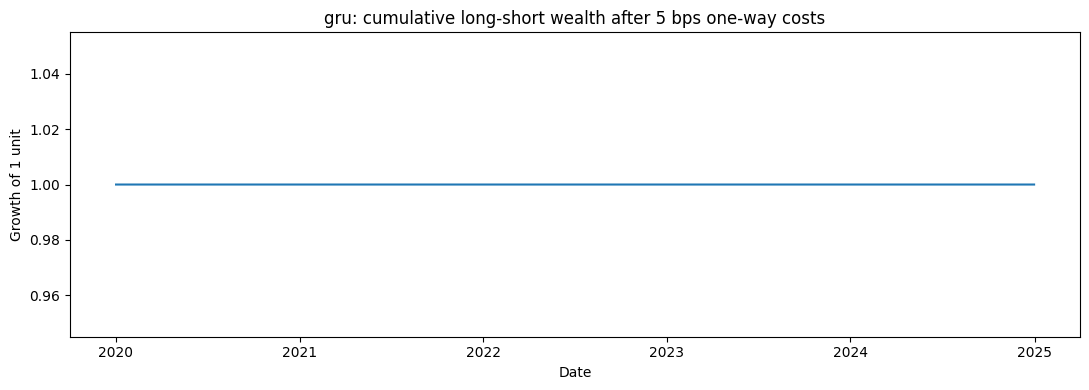

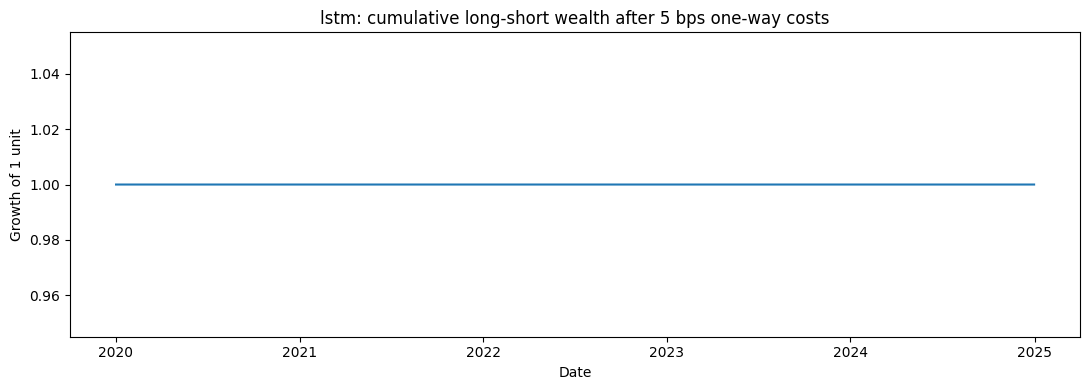

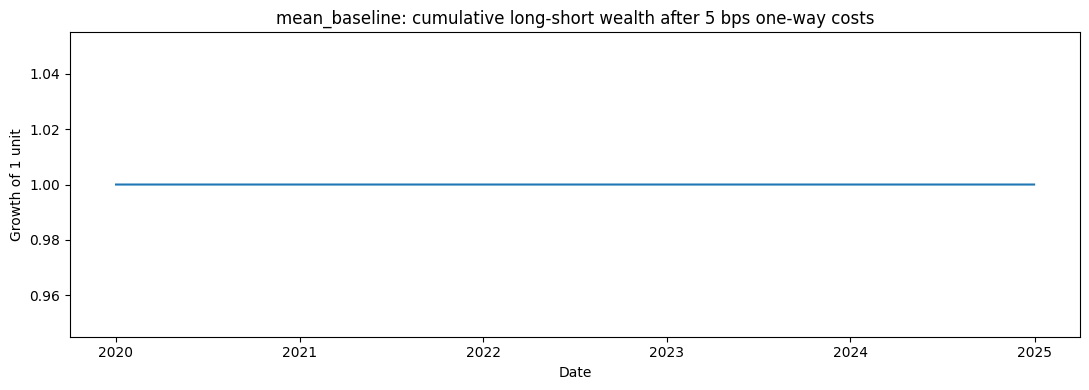

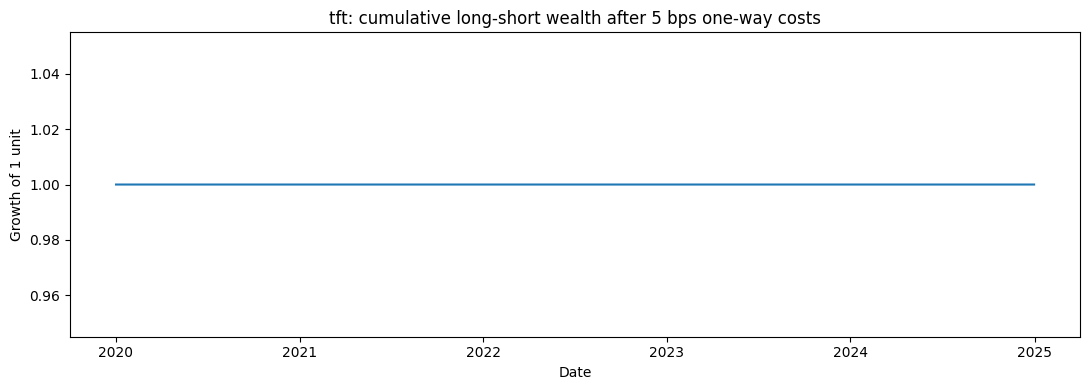

In [6]:
baseline_cost = 5

for model_name, group in portfolio_daily[
    portfolio_daily["cost_bps"] == baseline_cost
].groupby("model"):

    group = group.sort_values("date")
    cumulative = (1 + group["net_return"]).cumprod()

    plt.figure(figsize=(11, 4))
    plt.plot(group["date"], cumulative)
    plt.title(
        f"{model_name}: cumulative long-short wealth "
        f"after {baseline_cost} bps one-way costs"
    )
    plt.xlabel("Date")
    plt.ylabel("Growth of 1 unit")
    plt.tight_layout()
    plt.savefig('../reports/figures/portfolio_cumulative_returns.png', dpi=150, bbox_inches='tight')
plt.show()

## Optional factor-adjusted alpha

Run this only when daily Fama–French factors and momentum have been saved locally.

The regression checks whether portfolio returns are merely exposure to common risk factors.

The code expects decimal factor returns, not percentages.

In [7]:
RUN_FACTOR_ALPHA = False

if RUN_FACTOR_ALPHA:
    import statsmodels.api as sm

    factor_path = PROJECT_ROOT / "data" / "raw" / "ff_carhart_daily.csv"

    if not factor_path.exists():
        raise FileNotFoundError(
            f"Factor file not found: {factor_path}"
        )

    factors = pd.read_csv(
        factor_path,
        parse_dates=["date"],
    )

    factor_columns = ["MKT_RF", "SMB", "HML", "MOM", "RF"]

    missing_factors = set(factor_columns).difference(factors.columns)

    if missing_factors:
        raise ValueError(
            f"Factor file is missing: {sorted(missing_factors)}"
        )

    alpha_rows = []

    baseline_portfolios = portfolio_daily[
        portfolio_daily["cost_bps"] == 5
    ]

    for model_name, group in baseline_portfolios.groupby("model"):
        regression_data = group.merge(
            factors,
            on="date",
            how="inner",
        ).dropna()

        regression_data["excess_portfolio"] = (
            regression_data["net_return"] - regression_data["RF"]
        )

        x = sm.add_constant(
            regression_data[["MKT_RF", "SMB", "HML", "MOM"]]
        )

        fitted = sm.OLS(
            regression_data["excess_portfolio"],
            x,
        ).fit(
            cov_type="HAC",
            cov_kwds={"maxlags": 5},
        )

        alpha_rows.append({
            "model": model_name,
            "daily_alpha": fitted.params["const"],
            "annualised_alpha": fitted.params["const"] * 252,
            "alpha_pvalue": fitted.pvalues["const"],
        })

    factor_alpha_table = pd.DataFrame(alpha_rows)
    display(factor_alpha_table)
else:
    print("Factor-alpha section is disabled.")

Factor-alpha section is disabled.


In [8]:
portfolio_daily.to_parquet(
    DATA_PROCESSED / "portfolio_daily_results.parquet",
    index=False,
)

portfolio_summary.to_csv(
    REPORT_TABLES / "portfolio_summary_5_10_25_bps.csv",
    index=False,
)

print("Saved portfolio results.")

Saved portfolio results.


## What to say in the meeting

> Forecast metrics tell me whether predictions are numerically accurate. The portfolio test asks whether those predictions are economically useful. I rank stocks, buy the highest forecasts and short the lowest, then deduct realistic trading costs. A model is not practically valuable if a small statistical improvement disappears after turnover and costs.